# Notebook 03 — Content-Based Filtering (TF-IDF + Cosine Similarity)

**Responsable:** Estudiante A  
**Objetivo:** Recomendar películas similares basándose en su contenido (géneros, keywords, actores, director).

## Fundamento Matemático

### TF-IDF
Representa cada película como un vector donde el peso del token $t$ es:

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count}(t, d)}{|d|}}_{\text{TF}} \times \underbrace{\log\frac{1 + N}{1 + \text{df}(t)} + 1}_{\text{IDF}}$$

### Similitud Coseno
Dado que los vectores están normalizados ($\|v\|_2 = 1$):

$$\text{sim}(a, b) = \frac{a \cdot b}{\|a\| \|b\|} = a \cdot b$$

La matriz completa de similitudes es simplemente: $S = M \cdot M^T$

## Contenido
1. Cargar datos procesados
2. Construir matriz TF-IDF desde cero
3. Calcular similitud coseno
4. Función de recomendación
5. Ejemplos cualitativos
6. Análisis de la distribución de similitudes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.abspath('..'))

from src.models.tfidf import TFIDFVectorizer
from src.models.cosine_similarity import cosine_similarity_matrix, get_top_n

## 1. Cargar Datos

In [2]:
df = pd.read_csv('../data/processed/movies_clean.csv')
print(f'Dataset: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head(3)

Dataset: (4803, 9)
Columnas: ['id', 'title', 'tag_soup', 'genres_list', 'vote_average', 'vote_count', 'budget_log', 'revenue_log', 'release_year']


,id,title,tag_soup,genres_list,vote_average,vote_count,budget_log,revenue_log,release_year
0,19995,Avatar,action action adventure adventure fantasy fant...,"['Action', 'Adventure', 'Fantasy', 'Science Fi...",7.2,11800,19.283571,21.748578,2009.0
1,285,Pirates of the Caribbean: At World's End,adventure adventure fantasy fantasy action act...,"['Adventure', 'Fantasy', 'Action']",6.9,4500,19.519293,20.683485,2007.0
2,206647,Spectre,action action adventure adventure crime crime ...,"['Action', 'Adventure', 'Crime']",6.3,4466,19.316769,20.596199,2015.0


## 2. Construir Matriz TF-IDF

In [3]:
# El corpus son los tag_soup de cada película
corpus = df['tag_soup'].fillna('').tolist()

# Instanciar y ajustar el vectorizador (implementado desde cero en src/models/tfidf.py)
vectorizer = TFIDFVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

print(f'Vocabulario: {len(vectorizer.vocabulary_)} tokens únicos')
print(f'Matriz TF-IDF: {tfidf_matrix.shape}  (películas × tokens)')
print(f'Memoria: {tfidf_matrix.nbytes / 1e6:.1f} MB')

Vocabulario: 17583 tokens únicos
Matriz TF-IDF: (4803, 17583)  (películas × tokens)
Memoria: 675.6 MB


In [4]:
# Verificar que los vectores estén normalizados (norma ≈ 1)
norms = np.linalg.norm(tfidf_matrix, axis=1)
print(f'Norma mínima: {norms.min():.4f}')
print(f'Norma máxima: {norms.max():.4f}')
print(f'Vectores con norma ≈ 1: {(np.abs(norms - 1) < 1e-6).sum()} de {len(norms)}')

Norma mínima: 0.0000
Norma máxima: 1.0000
Vectores con norma ≈ 1: 4790 de 4803


## 3. Calcular Similitud Coseno

In [5]:
# Matriz de similitud coseno: shape (n_movies, n_movies)
# sim[i, j] = similitud entre película i y película j
sim_matrix = cosine_similarity_matrix(tfidf_matrix)

print(f'Matriz de similitud: {sim_matrix.shape}')
print(f'Similitud consigo misma (diagonal): {sim_matrix.diagonal().mean():.4f}  (debe ser ≈ 1)')
print(f'Similitud promedio (off-diagonal):  {sim_matrix[sim_matrix < 0.9999].mean():.4f}')

Matriz de similitud: (4803, 4803)
Similitud consigo misma (diagonal): 0.9973  (debe ser ≈ 1)
Similitud promedio (off-diagonal):  0.0170


## 4. Función de Recomendación

In [6]:
# Crear índice inverso: título → índice de fila
title_to_idx = pd.Series(df.index, index=df['title']).to_dict()

def get_recommendations(movie_title, n=10):
    """
    Retorna las N películas más similares a movie_title.

    Parámetros
    ----------
    movie_title : str
    n           : int

    Retorna
    -------
    pd.DataFrame con título, similitud y géneros.
    """
    if movie_title not in title_to_idx:
        print(f'Película "{movie_title}" no encontrada.')
        return None

    idx = title_to_idx[movie_title]
    similarity_scores = sim_matrix[idx]
    top_indices = get_top_n(similarity_scores, idx, n=n)

    result = df.iloc[top_indices][['title', 'genres_list', 'vote_average']].copy()
    result['similarity'] = similarity_scores[top_indices].round(4)
    result = result.sort_values('similarity', ascending=False)
    return result.reset_index(drop=True)

## 5. Ejemplos Cualitativos

In [7]:
# Ejemplo 1: película de ciencia ficción
print('=== Recomendaciones para "Interstellar" ===')
recs = get_recommendations('Interstellar', n=10)
if recs is not None:
    print(recs[['title', 'similarity', 'vote_average']].to_string(index=False))

=== Recomendaciones para "Interstellar" ===
                     title  similarity  vote_average
                 Inception      0.2103           8.1
               The Martian      0.2042           7.6
                 Apollo 13      0.1844           7.3
            Silent Running      0.1783           6.3
Stargate: The Ark of Truth      0.1707           6.9
              The Prestige      0.1664           8.0
                  Insomnia      0.1634           6.8
           The Dark Knight      0.1600           8.2
     2001: A Space Odyssey      0.1530           7.9
                Armageddon      0.1513           6.4


In [8]:
# Ejemplo 2: película de superhéroes
print('=== Recomendaciones para "The Dark Knight" ===')
recs = get_recommendations('The Dark Knight', n=10)
if recs is not None:
    print(recs[['title', 'similarity', 'vote_average']].to_string(index=False))

=== Recomendaciones para "The Dark Knight" ===
                   title  similarity  vote_average
   The Dark Knight Rises      0.5187           7.6
           Batman Begins      0.4627           7.5
            The Prestige      0.2553           8.0
                Insomnia      0.2477           6.8
          Batman & Robin      0.2436           4.2
          Batman Returns      0.2408           6.6
               Inception      0.2286           8.1
Amidst the Devil's Wings      0.2251           0.0
                  Batman      0.2165           7.0
                 Memento      0.1966           8.1


In [9]:
# Ejemplo 3: comedia
print('=== Recomendaciones para "The Avengers" ===')
recs = get_recommendations('The Avengers', n=10)
if recs is not None:
    print(recs[['title', 'similarity', 'vote_average']].to_string(index=False))

=== Recomendaciones para "The Avengers" ===
                              title  similarity  vote_average
            Avengers: Age of Ultron      0.7975           7.3
         Captain America: Civil War      0.4328           7.1
Captain America: The Winter Soldier      0.4179           7.6
                         Iron Man 2      0.3906           6.6
                            Ant-Man      0.3498           7.0
                           Serenity      0.3477           7.4
 Captain America: The First Avenger      0.3465           6.6
                           Iron Man      0.3136           7.4
                         Iron Man 3      0.2765           6.8
                               Thor      0.2688           6.6


## 6. Análisis de la Distribución de Similitudes

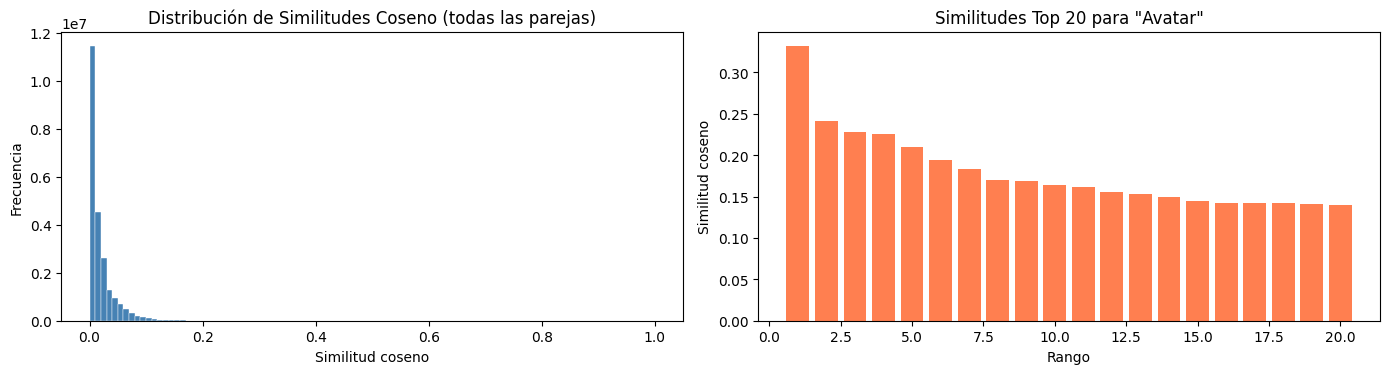


Estadísticas de similitud:
  Media:    0.0170
  Mediana:  0.0103
  Máx:      1.0000
  Pares con sim > 0.5: 882


In [10]:
# Distribución de todas las similitudes off-diagonal
mask = ~np.eye(sim_matrix.shape[0], dtype=bool)
all_sims = sim_matrix[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_sims, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribución de Similitudes Coseno (todas las parejas)')
axes[0].set_xlabel('Similitud coseno')
axes[0].set_ylabel('Frecuencia')

# Similitudes del top de una película de ejemplo
example_title = 'Avatar'
if example_title in title_to_idx:
    idx = title_to_idx[example_title]
    sims = np.sort(sim_matrix[idx])[::-1][1:21]  # top 20 (excluir self)
    axes[1].bar(range(1, 21), sims, color='coral')
    axes[1].set_title(f'Similitudes Top 20 para "{example_title}"')
    axes[1].set_xlabel('Rango')
    axes[1].set_ylabel('Similitud coseno')

plt.tight_layout()
plt.savefig('../reports/figures/similarity_distribution.png', dpi=150)
plt.show()

print(f'\nEstadísticas de similitud:')
print(f'  Media:    {all_sims.mean():.4f}')
print(f'  Mediana:  {np.median(all_sims):.4f}')
print(f'  Máx:      {all_sims.max():.4f}')
print(f'  Pares con sim > 0.5: {(all_sims > 0.5).sum():,}')

## 7. Guardar Artefactos para el Notebook de Evaluación

In [11]:
# Guardar la matriz de similitud y el índice de títulos
np.save('../data/processed/content_sim_matrix.npy', sim_matrix)
df[['id', 'title']].to_csv('../data/processed/movie_index.csv', index=True)
print('Artefactos de content-based guardados.')

Artefactos de content-based guardados.
